# DeepAFM

## Tutorial Overview

This notebook demonstrates the complete DeepAFM workflow using a small dataset.

### What you will learn
1. **AFM image generation**: Generate 10,000 synthetic AFM images from MD simulations (closed and wide-open conformations). MD simulation data contains 20,000 frames; only frames 1 and 20,000 are used in this tutorial(representing closed and wide-open states, respectively).

2. **Dataset construction**: Build train/validation/test datasets in WebDataset format with data augmentation (white noise and translation).
3. **Model training**: Train a ViT-based multi-task autoencoder (30 epochs).
4. **Evaluation**: Compute state-classification accuracy and reconstruction quality (MSE/MAE), and visualize attention rollout.

### Specifications
| Item | Value |
|------|-------|
| **Images** | 10,000 total (train/validation/test split: 8:1:1) |
| **Image size** | 36 × 36 pixels |
| **Scale** | 0.8 nm/pixel |
| **Model** | ViT multi-task autoencoder |
| **Encoder** | 4 layers, 128 dim, 4 heads |
| **Decoder** | 2 layers, 64 dim, 2 heads |
| **Classifier** | 2 layers, 128 dim, 4 heads |
| **Task** | Multi-task (conformational state estimation + denoising) |
| **Loss weights** | cls: 1, recon: 100 |
| **Batch size** | 64 |
| **Estimated time** | ~10 minutes (GPU recommended) |

### Requirements
- GPU is recommended (CPU is supported but slower).
- ~300 MB disk space for generated data and model outputs.
- Python packages from `requirements.txt`.
- **Zenodo dataset is required**:
  1. Download `18587081.zip` from Zenodo.
  2. Place it in the repository root.
  3. Run `bash setup.sh` to extract data into `data/md_raw/` 

## Setting

In [1]:
# Get current working directory and add ./src to sys.path
import os
import sys
from pathlib import Path
import torch

cwd = Path.cwd()
src_path = cwd / "src"

if src_path.exists():
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))
        print("Inserted src into sys.path")
    else:
        print("src already in sys.path")
        
else:
    print("No src directory found at expected path:", src_path)

Inserted src into sys.path


In [2]:
# Experiment Configuration
from configs.experiment_config import ExperimentConfig
from utils.setup_utils import make_experiment_dirs

# Define experiment configuration
protein_of_project = "SecYAEG_NDs"
exp_id = "Tutorial_of_{}".format(protein_of_project)

exp_cfg = ExperimentConfig(
    protein_of_project=protein_of_project,
    exp_id=exp_id, 
    scan_direction="x",
)

description = "DeepAFM tutorial experiment for protein {}".format(protein_of_project)
exp_cfg.description = description

make_experiment_dirs(exp_cfg)  # Create experiment directories

## AFM image Generation

In [3]:
from afm_image_generation.core.afm_image_generator_multiprocess import AFMImageGenerator_Multiprocess
from dataload.split_manager import split_and_move_data

### Configure Generation Parameters

In [4]:
# Make run name and save configuration
exp_cfg.system.run_name = exp_id

# Set SEED
exp_cfg.system.seed = 42 

# AFM Image Generation Settings
# save mode settings
exp_cfg.system.md_load_mode = "coarse"   # "all_atom", "coarse" 
exp_cfg.system.save_mode = "webdataset"  # Options: "hdf5", "tfrecord", "webdataset"
exp_cfg.system.use_gpu_for_afm = False     
exp_cfg.system.device = "cpu"            # use only cpu for AFM image generation

# Set AFM image generation parameters
exp_cfg.afm.random.scan_preset_list = [
    {"scale_x": 0.8, "scale_y": 0.8, "width_px": 36, "height_px": 36}
    ]
exp_cfg.afm.fixed.fixed_width_px = 36        # Set fixed width in pixels for saving AFM images
exp_cfg.afm.fixed.fixed_height_px = 36       # Set fixed height in pixels for saving AFM images

# range -> list1
exp_cfg.afm.random.__post_init__()  
exp_cfg.afm.random.pdb_num_list = [1, 20000]      # Set PDB frame number list (Closed or Wide-open) 

# AFM job settings
exp_cfg.afm.job.total_images = 10000              # Number of AFM images to generate
exp_cfg.afm.job.processes = 32                    # Number of processes for AFM image generation
exp_cfg.afm.job.chunk_size = 1000                 # Chunk size for saving AFM image
exp_cfg.afm.job.vectorized = False                # execute AFM image generation in vectorized mode
exp_cfg.afm.job.output_mode = [                   # Output mode for AFM image generation
    "distorted",  # Distorted AFM image accounting for asynchronous measurement times
    "ideal",      # Instantaneous AFM image
    "config"      # Parameters used for image generation
]

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file

### Generate AFM Images and Split Dataset

In [5]:
# Initialize AFM Image Generator with Multiprocessing
generator = AFMImageGenerator_Multiprocess(exp_cfg)

# Set up and run AFM image generation
generator.setup()
generator.run_parallel_process()

# shut down the generator after completion
generator.shutdown()

# Split generated data into train/val/test sets
save_mode_to_extension = {
    "hdf5": "hdf5",
    "tfrecord": "tfrecord",
    "webdataset": "tar",
}

split_and_move_data(
    exp_cfg, 
    extension=save_mode_to_extension[exp_cfg.system.save_mode]
    )


AFMInputGenerator: parameter_mode = random


[AFM Multiprocess] Configured for 10000 images using 32 processes with chunk size 1000.
[AFM Multiprocess] Use GPU for AFM: False
[AFM Multiprocess] Save mode set to: webdataset
[AFM Multiprocess] Scan direction: x, Scan unit: line


2026-03-04 19:36:48,592	INFO worker.py:1951 -- Started a local Ray instance.


2026-03-04 19:36:48,755	INFO packaging.py:588 -- Creating a file package for local module '/home/ksatou/2025_DeepAFM_Pytorch/DeepAFM/src'.


2026-03-04 19:36:48,921	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_a1e1c3631130bc27.zip' (37.90MiB) to Ray cluster...


...

[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.


[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.


[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.
[INFO] Reached total_images. Stopping submission.


[WebDataset] Saved chunk → data/Tutorial_of_SecYAEG_NDs/afm_generated/42_0009.tar


[Shutdown] Ray environment closed successfully.


## Data loader

In [6]:
from dataload.webdataset_loader import create_afm_dataloader

# device settings for data loading and preprocessing
exp_cfg.system.device = "cuda" if torch.cuda.is_available() else "cpu"

# set data load modes
exp_cfg.system.data_load_mode = ["distorted", "ideal", "config"]

# set preprocess and data augmentation 
# add white noise option
exp_cfg.data.add_white_noise = True
exp_cfg.data.noise_std_range = (0.0, 0.3, 0.01)  # Range of noise stddev for augmentation

# translation range in pixels
exp_cfg.data.translation_x_pixel = (-3, 3, 1)    # set translation range in pixels
exp_cfg.data.translation_y_pixel = (-3, 3, 1)    # set translation range in pixels
exp_cfg.data.__post_init__()                     # expand ranges to lists

# scaling option
exp_cfg.data.min_max_scaling = True

# pdb number to state mapping
exp_cfg.data.pdb_num_to_state = True            # enable pdb_num to state mapping
exp_cfg.train.batch_size = 64                   # Batch size for training

# set pdb_num-to-state mapping mode ("unsupervised" or "custom")
# if "unsupervised", map PDB numbers to states based on unsupervised learning results
# details in src/dataload/preprocess.py::_pdb_num_to_state
# custom mode allows users to specify their own mapping from PDB frame numbers to state labels, 
# which is useful for tutorial purposes or when the mapping is known a priori.

exp_cfg.data.pdb_num_to_state_mapping_mode = "custom"  

# for custom mapping mode, specify the mapping from pdb frame number to state label
exp_cfg.data.custom_mapping = {
    1: 0,       # PDB frame number 1 -> state 0
    20000: 1    # PDB frame number 20000 -> state 1
}

# task mode
exp_cfg.train.task_mode = "multitask"

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file

train_dataloader = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.train_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    shuffle=True
    )

val_dataloader = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.val_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    shuffle=False
    )


## Training

In [7]:
from configs.nn_config import ViTMultiTaskAutoEncoderConfig
from models.ViT_MultiTask_AutoEncoder import ViTMultiTaskAutoEncoder
from builders.loss_builder import build_loss
from builders.metrics_builder import build_metrics  
from builders.optimizer_builder import build_optimizer
from builders.scheduler_builder import build_scheduler
from training.trainer import ModelTrainer

In [8]:
# Training ViT for DeepAFM
exp_cfg.system.run_name = exp_id
exp_cfg.system.nn_dtype = "fp32" 
exp_cfg.train.use_amp = False # If use GPU with AMP, set to True is recommended

# Set ViT model parameters
exp_cfg.model = ViTMultiTaskAutoEncoderConfig()    # Use ViTMultiTaskAutoEncoderConfig for AE
exp_cfg.model.image_size = 36                      # Image size for ViT
exp_cfg.model.patch_size = 4                       # Patch size for ViT
exp_cfg.model.enc_embed_dim = 128                  # Embedding dimension for ViT
exp_cfg.model.enc_depth = 4                        # Depth of ViT model
exp_cfg.model.enc_num_heads = 4                    # Number of attention heads for ViT
exp_cfg.model.enc_mlp_ratio = 4                    # MLP ratio for ViT

exp_cfg.model.dec_embed_dim = 64                   # Embedding dimension for ViT
exp_cfg.model.dec_depth = 2                        # Depth of ViT model
exp_cfg.model.dec_num_heads = 2                    # Number of attention heads for ViT
exp_cfg.model.dec_mlp_ratio = 4                    # MLP ratio for ViT

exp_cfg.model.class_depth = 2                      # Depth of classifier head
exp_cfg.model.num_classes = 2                      # Number of classes for classification task

# scheduler settings
exp_cfg.train.scheduler = "cosine"                 # Learning rate scheduler type

# dataload settings
exp_cfg.data.num_workers = 32                      # Number of worker processes for data loading
exp_cfg.data.prefetch_size = 1                     # Prefetch size for data loading

# Set training parameters for ViT
exp_cfg.train.epochs = 30                         # Number of training epochs
# task mode
exp_cfg.train.task_mode = "multitask"             # "denoise" or "multitask"
# loss weights for multitask
exp_cfg.train.recons_loss_type = "mse"            # for denoise/reconstruction task: "mse", "l1", "huber"
exp_cfg.train.weight_cls = 1                      # weight for classification loss   
exp_cfg.train.weight_recon = 100                  # weight for reconstruction(denoise) loss

# save experiment configuration to YAML file
exp_cfg.save_yaml()  # Save the configuration to a YAML file


In [9]:
#  --- Training ---
model = ViTMultiTaskAutoEncoder.from_config(exp_cfg)

loss_fn, loss_weights = build_loss(exp_cfg)
metrics = build_metrics(exp_cfg)
optimizer = build_optimizer(exp_cfg, model)
scheduler = build_scheduler(exp_cfg, optimizer)

trainer = ModelTrainer(
    exp_cfg=exp_cfg, 
    model=model,
    loss_fn=loss_fn,
    loss_weights=loss_weights,
    metrics=metrics,
    optimizer=optimizer,
    train_loader=train_dataloader, 
    val_loader=val_dataloader,
    scheduler=scheduler
    )

trainer.fit()

[Trainer] No checkpoints found, start from scratch.
[Trainer] Starting training for 30 epochs
[Trainer] Starting training from epoch 1


 >> New Best Model found! Val Loss: 1.415218
[Checkpoint] Saved best model: runs/Tutorial_of_SecYAEG_NDs/checkpoints/best_model.pt
Epoch 1 | LR: 9.97e-05 | train_ideal_mae: 0.1384 | train_ideal_mse: 0.0427 | train_loss: 4.9672 | train_loss_ideal: 0.0427 | train_loss_state: 0.7019 | train_state_acc: 0.5011 | val_ideal_mae: 0.0461 | val_ideal_mse: 0.0070 | val_loss: 1.4152 | val_loss_ideal: 0.0070 | val_loss_state: 0.7116 | val_state_acc: 0.4810


 >> New Best Model found! Val Loss: 1.167011
[Checkpoint] Saved best model: runs/Tutorial_of_SecYAEG_NDs/checkpoints/best_model.pt
Epoch 2 | LR: 9.89e-05 | train_ideal_mae: 0.0674 | train_ideal_mse: 0.0091 | train_loss: 1.6077 | train_loss_ideal: 0.0091 | train_loss_state: 0.6975 | train_state_acc: 0.5145 | val_ideal_mae: 0.0386 | val_ideal_mse: 0.0047 | val_loss: 1.1670 | val_loss_ideal: 0.0047 | val_loss_state: 0.6981 | val_state_acc: 0.5190


 >> New Best Model found! Val Loss: 1.131772
[Checkpoint] Saved best model: runs/Tutorial_of_SecYAEG_NDs/checkpoints/best_model.pt
Epoch 3 | LR: 9.76e-05 | train_ideal_mae: 0.0571 | train_ideal_mse: 0.0068 | train_loss: 1.3763 | train_loss_ideal: 0.0068 | train_loss_state: 0.6940 | train_state_acc: 0.5194 | val_ideal_mae: 0.0355 | val_ideal_mse: 0.0043 | val_loss: 1.1318 | val_loss_ideal: 0.0043 | val_loss_state: 0.7033 | val_state_acc: 0.4810


 >> New Best Model found! Val Loss: 1.104453
[Checkpoint] Saved best model: runs/Tutorial_of_SecYAEG_NDs/checkpoints/best_model.pt
Epoch 4 | LR: 9.57e-05 | train_ideal_mae: 0.0518 | train_ideal_mse: 0.0059 | train_loss: 1.2894 | train_loss_ideal: 0.0059 | train_loss_state: 0.6945 | train_state_acc: 0.5159 | val_ideal_mae: 0.0338 | val_ideal_mse: 0.0041 | val_loss: 1.1045 | val_loss_ideal: 0.0041 | val_loss_state: 0.6941 | val_state_acc: 0.4930


...

Epoch 30 | LR: 0.00e+00 | train_ideal_mae: 0.0351 | train_ideal_mse: 0.0040 | train_loss: 1.0761 | train_loss_ideal: 0.0040 | train_loss_state: 0.6796 | train_state_acc: 0.5679 | val_ideal_mae: 0.0294 | val_ideal_mse: 0.0036 | val_loss: 1.0498 | val_loss_ideal: 0.0036 | val_loss_state: 0.6903 | val_state_acc: 0.5290
[Checkpoint] Saved: runs/Tutorial_of_SecYAEG_NDs/checkpoints/model_epoch30.pt


[Logger] Saved plot: curve_Learning_Rate.png
[Logger] Saved plot: curve_loss.png


[Logger] Saved plot: curve_loss_ideal.png
[Logger] Saved plot: curve_loss_state.png


[Logger] Saved plot: curve_ideal_mae.png
[Logger] Saved plot: curve_ideal_mse.png


[Logger] Saved plot: curve_state_acc.png


## Evaluation

In [10]:
from evaluation.evaluater import Evaluator
from dataload.preprocess import AFMPreprocess

In [11]:
# --- Dataload for Evaluation ---
preprocessor = AFMPreprocess(
    exp_cfg=exp_cfg,
    add_white_noise=False,
    translate=False,
    min_max_scaling=True,
    pdb_num_to_state=True,
    )

test_dataloader = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.test_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    preprocessor=preprocessor,
    shuffle=False
    )

# --- Evaluation ---
model = ViTMultiTaskAutoEncoder.from_config(exp_cfg)
evaluator = Evaluator(
    exp_cfg=exp_cfg, 
    model=model,
    test_data_loader=test_dataloader
    )
# Build loss and metrics for evaluation
loss_fn, loss_weights = build_loss(exp_cfg)
metrics = build_metrics(exp_cfg)

#evaluator.load_latest_checkpoint()
evaluator.load_best_checkpoint()

# Compute loss and metrics
results = evaluator.compute_loss_and_metrics(
    loss_fn=loss_fn, 
    loss_weights=loss_weights, 
    metrics=metrics
    )

print("ACCURACY:", results['test_state_acc'])
print("MSE:", results['test_ideal_mse'])
print("MAE:", results['test_ideal_mae'])

# Compute confusion matrix
evaluator.compute_confusion_matrix()

[Evaluator] Loading latest checkpoint: runs/Tutorial_of_SecYAEG_NDs/checkpoints/model_epoch30.pt
[Evaluator] Loaded model at epoch 30
[Evaluator] Loading best checkpoint: runs/Tutorial_of_SecYAEG_NDs/checkpoints/best_model.pt


[Evaluator] Loaded model at epoch 25


[Evaluator] Saved evaluation results to runs/Tutorial_of_SecYAEG_NDs/evaluation_results/evaluation_results.txt
ACCURACY: 0.577
MSE: 0.0035067663192749022
MAE: 0.028000070571899415


[Evaluator] Saved confusion matrix to runs/Tutorial_of_SecYAEG_NDs/evaluation_results/confusion_matrix.npy


[Evaluator] Saved confusion matrix to runs/Tutorial_of_SecYAEG_NDs/evaluation_results/confusion_matrix.pdf


[Evaluator] Loading latest checkpoint: runs/Tutorial_of_SecYAEG_NDs/checkpoints/model_epoch30.pt
[Evaluator] Loaded model at epoch 30


[Evaluator] Loading best checkpoint: runs/Tutorial_of_SecYAEG_NDs/checkpoints/best_model.pt


[Evaluator] Loaded model at epoch 25


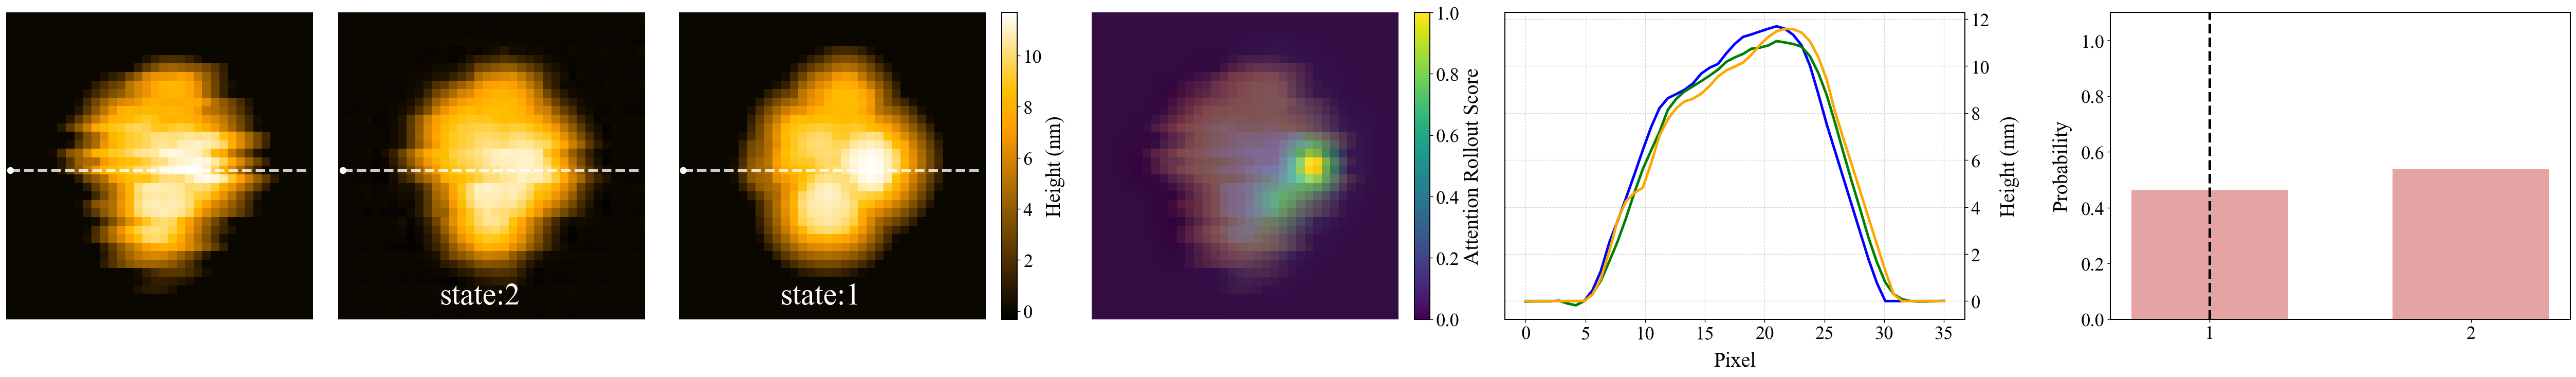

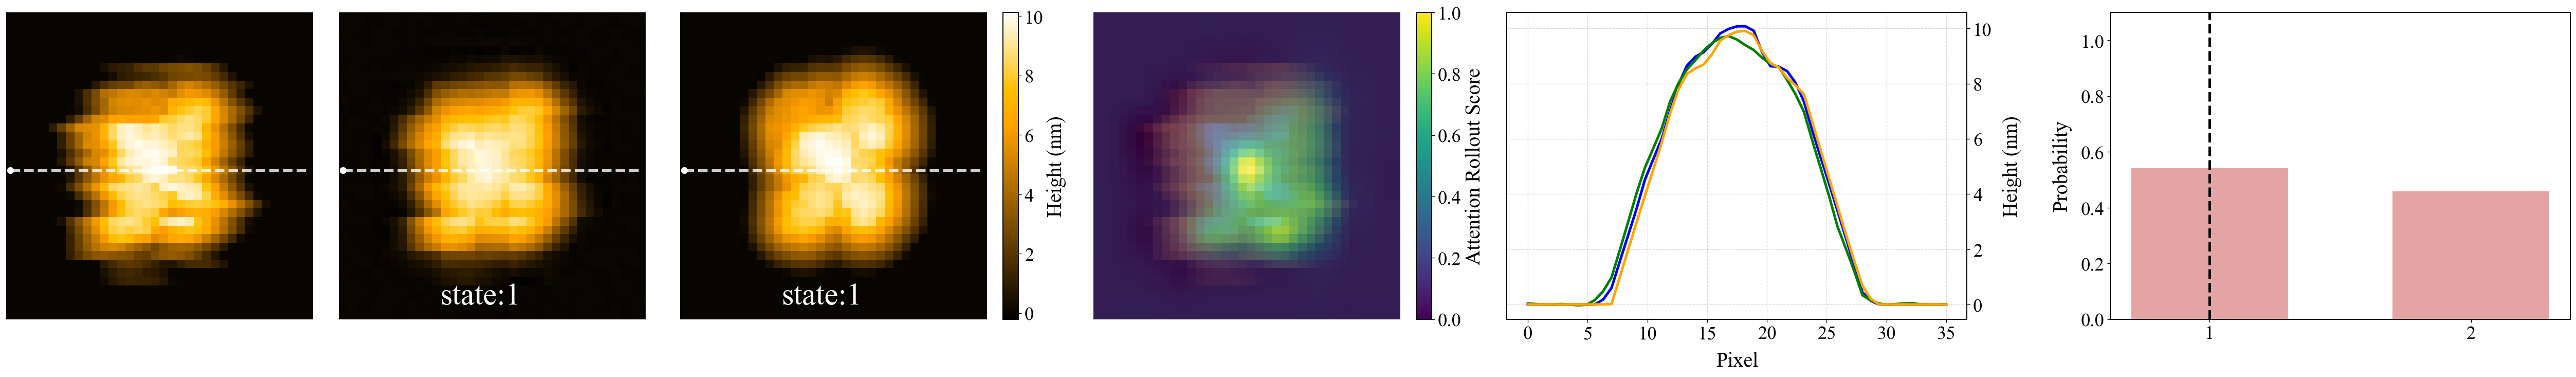

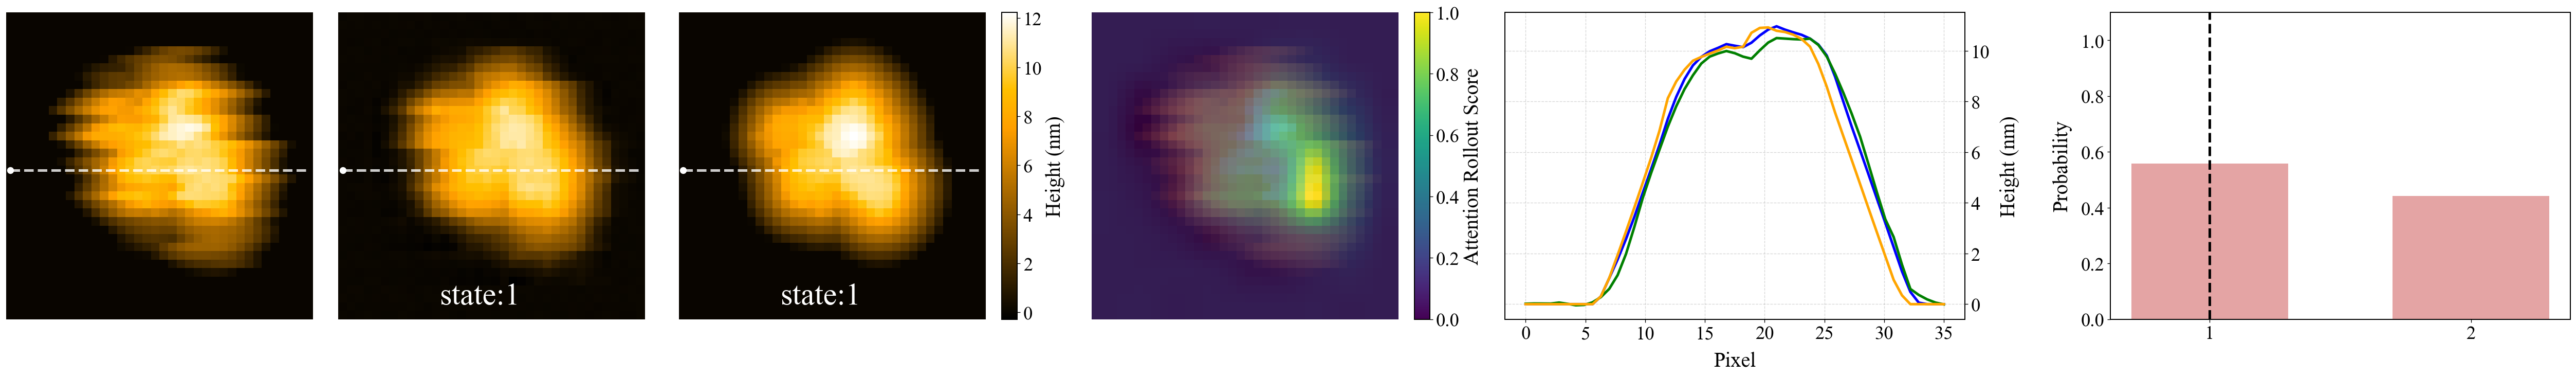

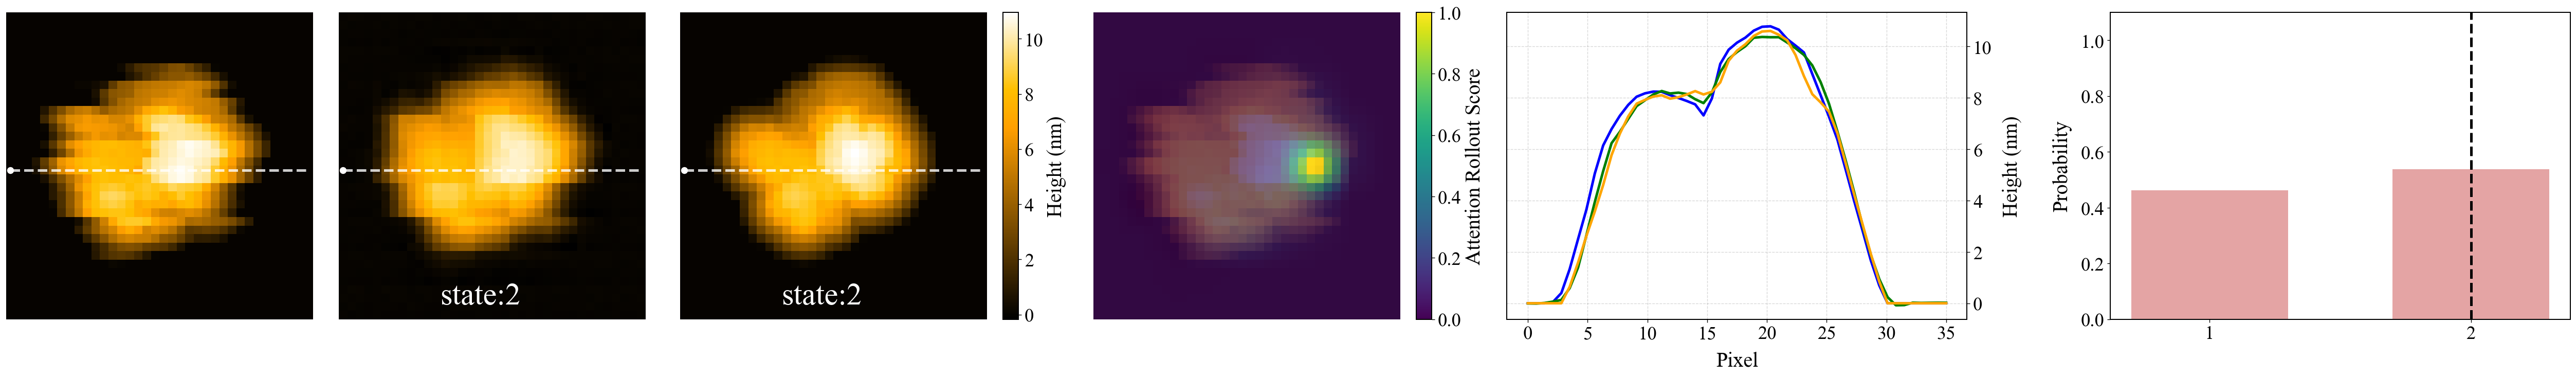

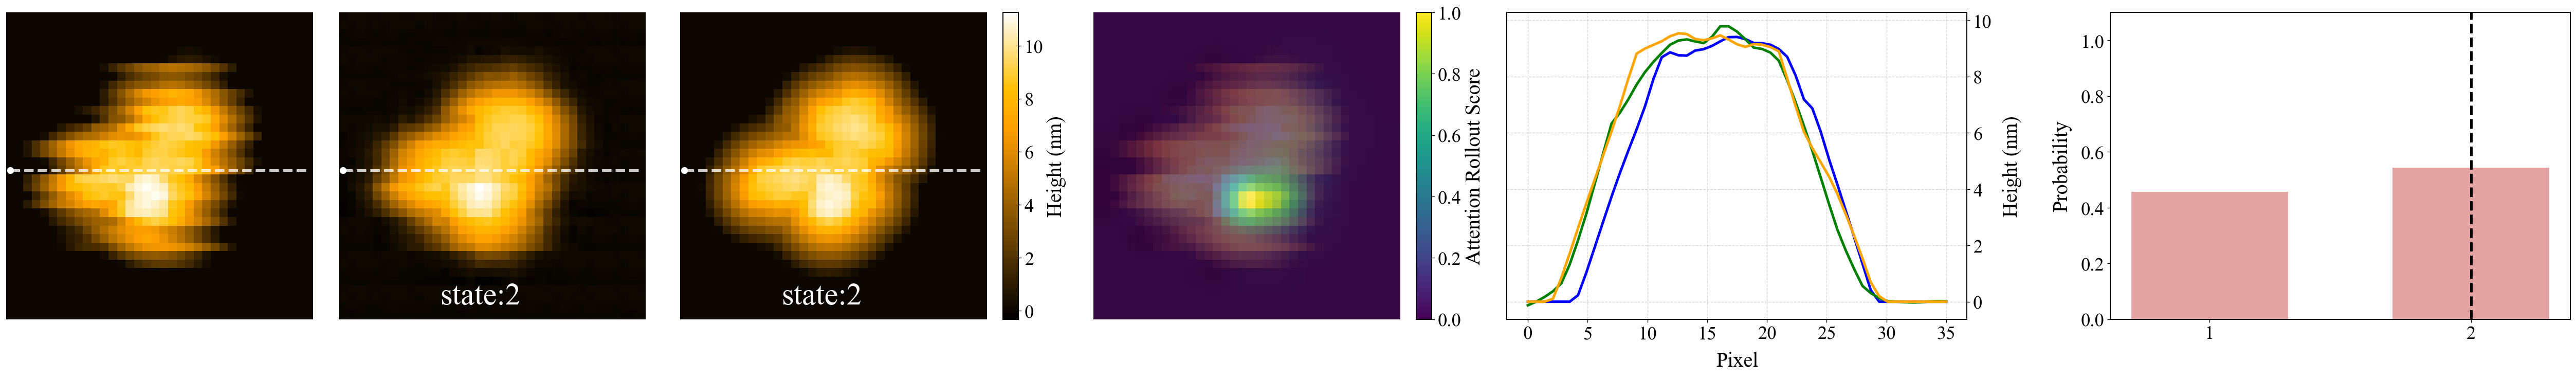

[Evaluator] Saved metrics log to runs/Tutorial_of_SecYAEG_NDs/evaluation_results/multitask_comprehensive/evaluation_metrics.csv (Total 5 samples)


In [12]:
# Visualization
IMG_NUMS = 5
IMAGE_SIZE = exp_cfg.model.image_size
ATTN_ANA_MODE = "classification_only"   # attention analysis mode: # "classification" or "classification_only" 

# preprocessor for visualization (no min-max scaling)
preprocessor = AFMPreprocess(
    exp_cfg=exp_cfg,
    add_white_noise=False,
    translate=False,
    min_max_scaling=False,
    pdb_num_to_state=True,
    )

test_dataloader = create_afm_dataloader(
    url_pattern=os.path.join(exp_cfg.data_dir.test_data_dir, "*.tar"), 
    exp_cfg=exp_cfg,
    preprocessor=preprocessor,
    shuffle=False
    )

evaluator = Evaluator(
    exp_cfg=exp_cfg, 
    model=model,
    test_data_loader=test_dataloader
    )

evaluator.load_best_checkpoint()

# Comprehensive Multi-Task Visualization
evaluator.visualize_multitask_comprehensive(
    dataloader=test_dataloader,
    num_samples=IMG_NUMS,
    start=(int(IMAGE_SIZE/2), 0),
    angle_deg=0,
    analyze_task=ATTN_ANA_MODE,
    save=False
    )
